# Second notebook on the analysis of P170+20
Second stage of the analysis focused on quantitative model comparison and best-fit selection.

In the first notebook, the observational data were normalized, rescaled to photometric reference points, resampled into uniform wavelength bins, and tested against preliminary stellar (M, L, T brown dwarfs / cool stars) and quasar/galaxy templates.

This notebook:

Resamples the finalized dataset and template models under consistent binning
Applies uniform scaling conditions
Compares stellar and quasar/galaxy templates
Evaluates goodness-of-fit across candidate models
Identifies the most plausible physical scenario
Produces comparative visualizations of the best-fit model
The objective is structured hypothesis evaluation through controlled template-based model comparison.

In [1]:
#Import libraries
import numpy as np
import matplotlib.pyplot  as plt
import astropy
from astropy.io import fits
from photutils.aperture import aperture_photometry
#not. sure about these two
from photutils.aperture import CircularAnnulus, CircularAperture, SkyCircularAperture, SkyCircularAnnulus 
from photutils.aperture import ApertureStats
from astropy.visualization import simple_norm
from astropy.wcs import WCS
import os
from astropy.coordinates import SkyCoord
from astropy import units as u
#from sculptor import speconed as sod
#import pkg_resources
from astropy import units as u
#from sculptor import speconed as sod
from astropy import units as u
from astropy.table import Table
from scipy.optimize import curve_fit
import pkg_resources

In [2]:
#Redshift to test
z=6.41

<Table length=960>
    name     dtype   unit                 description                
----------- ------- ------ ------------------------------------------
       Wave float64 0.1 nm                    Wavelength in Angstroms
      FluxD float64     --        Flux density PS1 composite spectrum
          N   int32     --       Number of quasars per wavelength bin
FluxD(hlya) float64     -- Flux density strong lya composite spectrum
FluxD(llya) float64     --   Flux density weak lya composite spectrum


(7410.0, 10963.095)

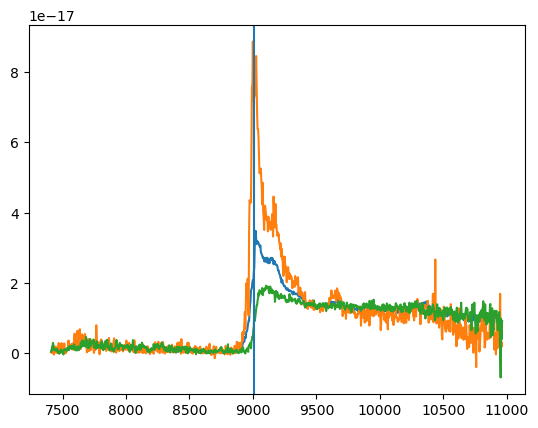

In [3]:
#Import data from Banados 2016 template / scale to flux units and redshift
compositehrspectra=Table.read('compositespectra.txt',format='ascii')
compositehrspectra.info()
composite_flux=compositehrspectra['FluxD']*1e-16/(z+1)
composite_fluxhl=compositehrspectra['FluxD(hlya)']*1e-16/(z+1)
composite_fluxll=compositehrspectra['FluxD(llya)']*1e-16/(z+1)
composite_wave=compositehrspectra['Wave']*(z+1)
plt.plot(composite_wave,composite_flux)
plt.plot(composite_wave,composite_fluxhl)
plt.plot(composite_wave,composite_fluxll)
plt.axvline(1216*(z+1))
composite_wave[0],composite_wave[-1]

(7410.741, 84101.277)

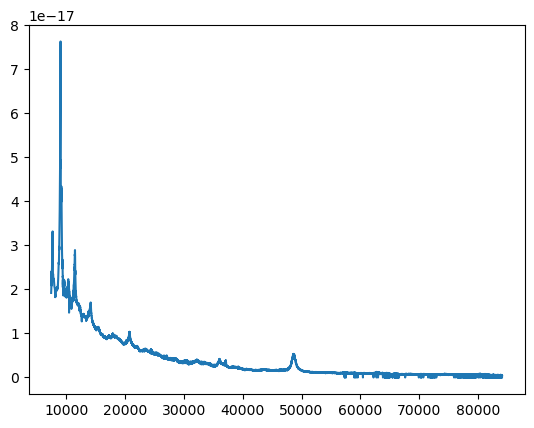

In [4]:
#Import data from Selsing template / scale to flux units and redshift
data = np.loadtxt('Selsing2015.dat', delimiter=' ')
wl=data[:,0]*(z+1)
weighted_mean=data[:,1]*1e-17/(z+1)
error_of_weighted_mean=data[:,2]*1e-17/(z+1)
#Plot to see Selsing data
plt.plot(wl,weighted_mean)
#Print first and last wavelength
wl[0],wl[-1]

In [5]:
#Load original data from Gemini (GMOS and F2)
originaldata=Table.read('spectra_gmos_fla_2_v2.txt', format='ascii')
#Check columns and dtype
originaldata.info

<Table length=4588>
   name     dtype 
---------- -------
WAVELENGTH float64
      FLUX float64
       ERR float64

In [6]:
#Load LBT data (scale to PanSTARSS) / gap within original data
lbtdata=Table.read('P170+20_LUCI_coadd_zps_tellcorr.fits')
#Check columns
lbtdata.info

<Table length=2069>
     name      dtype 
------------- -------
         wave float64
wave_grid_mid float64
         flux float64
         ivar float64
        sigma float64
         mask   int64
     telluric float64
    obj_model float64

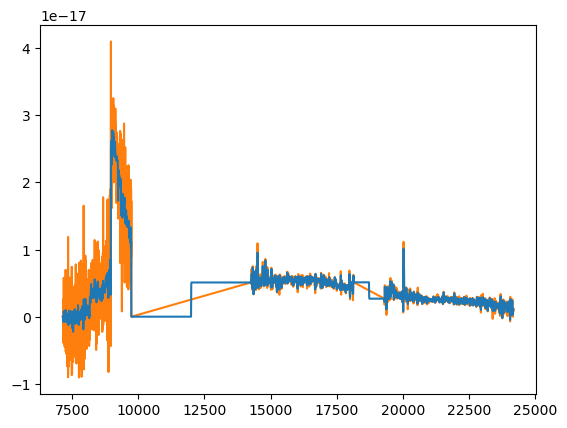

In [8]:
#Resample original data with FluxConservingResampler
#Include resample data/ pix_size=7.7 of GMOS data (lowest size)
import astropy.units as units
from specutils.manipulation import FluxConservingResampler
#First Give units to variables with filtered data
#First with original data
newflux=originaldata['FLUX']* units.erg/units.s/units.cm**2/units.AA
newwave=originaldata['WAVELENGTH']*1.*units.AA
newerr=originaldata['ERR'] * units.erg/units.s/units.cm**2/units.AA

#convert to SpectrumID object from specutils 
from specutils import Spectrum1D
input_spec=Spectrum1D(spectral_axis=newwave,flux=newflux) 
input_spec_err=Spectrum1D(spectral_axis=newwave,flux=newerr)

#Resample here
new_disp_grid = np.arange(5300, 24185.793, 7.7) * u.AA # inwave,finwave,pixsize (first and last wave from original data+GMOS pix size)
#Create object to resample
fluxcon = FluxConservingResampler()
#Resample flux data and error
new_spec_fluxcon = fluxcon(input_spec, new_disp_grid)
new_spec_fluxcon_err = fluxcon(input_spec_err, new_disp_grid)

#Plot original data and resampled original data
plt.plot(new_spec_fluxcon.spectral_axis,new_spec_fluxcon.flux)
plt.plot(newwave,newflux,zorder=1)

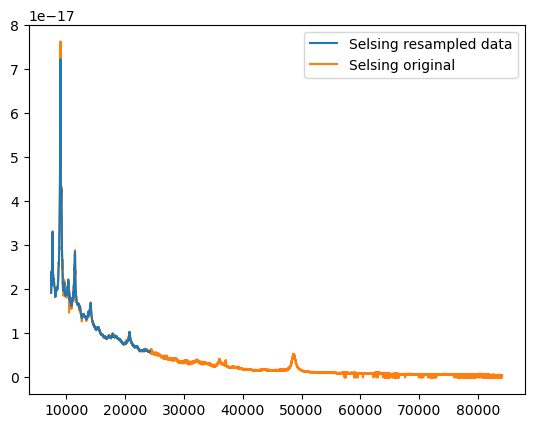

In [10]:
#Resample templates ----> Selsing
#Include resample data/ pix_size=7.7
#Selsing data
newfluxs=weighted_mean* units.erg/units.s/units.cm**2/units.AA
newwaves=wl*units.AA
newerrs=error_of_weighted_mean* units.erg/units.s/units.cm**2/units.AA

#Convert to Spectrum1D
input_specs=Spectrum1D(spectral_axis=newwaves,flux=newfluxs) 
input_spec_errs=Spectrum1D(spectral_axis=newwaves,flux=newerrs)

#Resample here using same object fluxcons and grid
new_spec_fluxcons = fluxcon(input_specs, new_disp_grid)
new_spec_fluxcon_errs = fluxcon(input_spec_errs, new_disp_grid)

#Plot Selsing data before and after
plt.plot(new_spec_fluxcons.spectral_axis,new_spec_fluxcons.flux, label='Selsing resampled data')
plt.plot(newwaves,newfluxs,zorder=1, label='Selsing original')
plt.legend()

### Note: Selsing data was shortened because of the resample to match all the rest of the available data

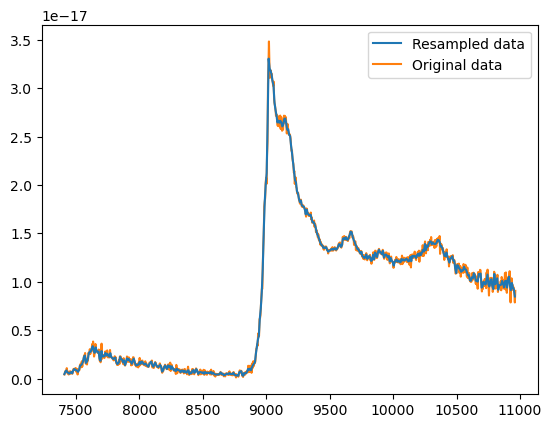

In [12]:
#Resample templates ----> Banados Intermediate (The chosen template to fit-Lyman alpha intermediate)
#Banados intermediate data
newfluxc=composite_flux.value*units.erg/units.s/units.cm**2/units.AA 
newwavec=composite_wave.value*1.*units.AA

#convert to Spectrum 
input_specc=Spectrum1D(spectral_axis=newwavec,flux=newfluxc) 

#Resample same grid same object
new_spec_fluxconc = fluxcon(input_specc, new_disp_grid)

#Plot Banados data before and after resample
plt.plot(new_spec_fluxconc.spectral_axis,new_spec_fluxconc.flux,label='Resampled data')
plt.plot(newwavec,newfluxc,zorder=1,label='Original data')
plt.legend()

## Here all the resampled data -> Join templates: Intermediate Comp Spectra with Selsing

In [14]:
#Rename resampled data again
#Original data (join GMOS and LBT data)
originaldata_wave=new_spec_fluxcon.spectral_axis.value #np.append(new_spec_fluxcon.spectral_axis.value,lbt_spec_fluxcon.spectral_axis.value)
originaldata_flux=new_spec_fluxcon.flux.value#np.append(new_spec_fluxcon.flux.value,lbt_spec_fluxcon.flux.value)


#Selsing data
wl=new_spec_fluxcons.spectral_axis.value
weighted_mean=new_spec_fluxcons.flux.value
#Banados data composite/intermediate
composite_wave=new_spec_fluxconc.spectral_axis.value
composite_flux=new_spec_fluxconc.flux.value

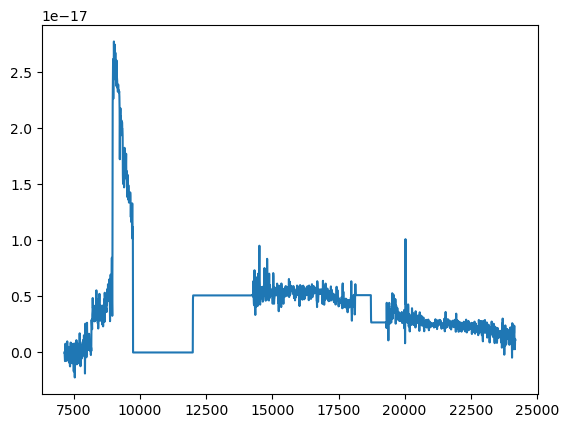

In [15]:
plt.plot(originaldata_wave,originaldata_flux)

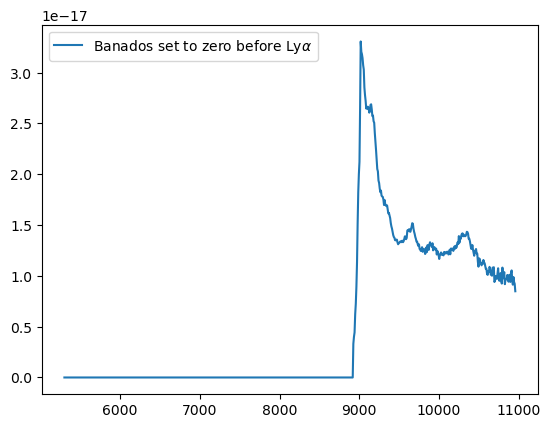

In [16]:
#Set banados template to zero before the break (we do not want any contribution of the template before Lyalpha)
maskzero=composite_wave < 1216*(1+z)-90
composite_flux= np.where(maskzero, 0, composite_flux)
#Plot to see template set to zero
plt.plot(composite_wave,composite_flux, label=r'Banados set to zero before Ly$\alpha$')
plt.legend()

In [17]:
#Check last wavelegth of Banados template
composite_flux[-1]

nan

## Here is the joined templates
Templates are joined to the last wavelength of the Banados template 1479.5
To match W1 photometric point 3.6 needs to be multiplied, to match the J band 1.8

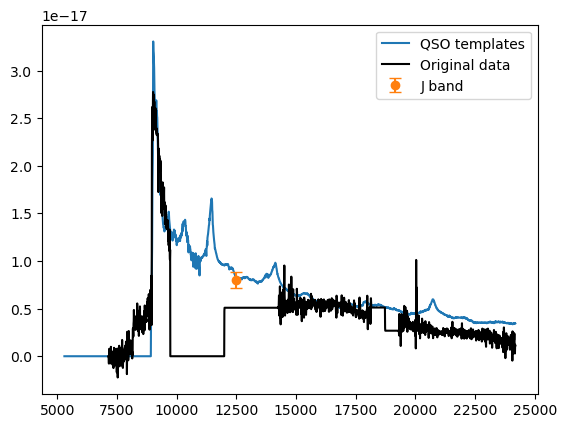

In [19]:
#Scale Selsing with comp/intermediate lyman alpha 
#Mask for the selsing template
maskcs2=wl>1479.5*(z+1)
#Mask for the banados template (in theory wave must be the same for resample)
maskpr=composite_wave<1479.5*(z+1)

#Create masks to calculate an average in a certain region to find the correct number to re scale the data / we do not use J1 or W1
masksjoin=(wl>10850)&(wl<10900)
selsingjoin=(composite_wave>10850)&(composite_flux<10900)
avgbanadosjoin=np.median(composite_flux[masksjoin])
averageselsingjoin=np.median(weighted_mean[selsingjoin])
averagejoin=avgbanadosjoin/averageselsingjoin

#Factor to test the data
factorj=4.2
#Factor to actually re scale the data
factorq=averagejoin

#Create new template for quasar contribution (Banados + Selsing) and save it in a table
tabc = astropy.table.Table()
tabc['WAVE']= np.append(composite_wave[maskpr],wl[maskcs2])
tabc['FLUX']= np.append(composite_flux[maskpr],weighted_mean[maskcs2]*factorq) #Note: this is multiplied by the factor to match data

#Plot templates, data and photometric points
#plt.plot(wl[selsingjoin], weighted_mean[selsingjoin],label='zone',color='magenta')
plt.plot(tabc['WAVE'],tabc['FLUX'],label='QSO templates')
plt.plot(originaldata_wave,originaldata_flux,label='Original data',color='black')
plt.plot()
#plt.errorbar(x=34000, y=7.19e-19, yerr=0.85e-18, fmt='o', capsize=4,label='W1 band')
#plt.errorbar(x=46000, y=2.28e-19, yerr=0.8e-18, fmt='o', capsize=4,label='W2 band')
#plt.plot(data[:,0]*(z+1),(data[:,1]*1e-17/(z+1))/factorj,label='selsing template') #to match with j band
plt.errorbar(x=12500, y=8.014e-18, yerr=0.85e-18, fmt='o', capsize=4,label='J band')
#plt.xlim(10000,12000)# to check break
#plt.xlim(30000,40000) #to check WI factors3=3.6
#plt.xlim(10000,13000) #to check the j band
#hERE TO CHeCK W1
#plt.plot(newwaves,newfluxs/2.1,zorder=1)
#plt.plot(composite_wave,composite_flux,label='banados template',linestyle='dotted')
#plt.plot(wl,weighted_mean,label='selsing template')
#tabc['FLUX'][27]

#plt.axvline(8980,color='red',label)

len(tabc['FLUX']),len(originaldata_flux),averagejoin,10850/(z+1),10900/(z+1)
plt.legend()

# Build model 
1. For the model we take first the new template QSO (Intermediate Lyalpha+Selsing) and we substract from the original data

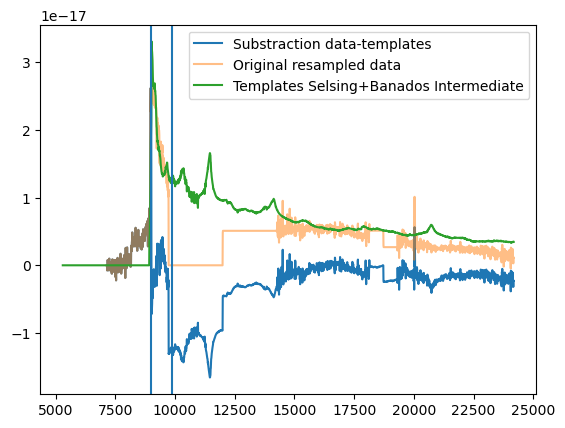

In [21]:
#Substraction data-model CLyman/Selsing
maskl=originaldata_wave>1216*(1+z) #mask to rest from Lyman alpha
maskl2=originaldata_wave<1216*(1+z)
a=originaldata_flux
d=tabc['FLUX']

#Do the substraction and save it in a new variable
result3 = a-d 
residual3=np.append(originaldata_flux[maskl2],result3[maskl]) #resta de data -templates sin contar zona mas alla de lyman

#Plot the substracted data
plt.plot(originaldata_wave,  residual3,label='Substraction data-templates' )
plt.plot(originaldata_wave,originaldata_flux,alpha=0.5,label='Original resampled data')
plt.plot(tabc['WAVE'],tabc['FLUX'],zorder=2,label='Templates Selsing+Banados Intermediate')
#plt.xlim(7700,10000)
plt.axvline(9000)
plt.axvline(1330*(z+1))
plt.legend()

# Here we test the models 
The M-dwarf models

In [23]:
pwd

'C:\\Users\\aurom\\Downloads\\Auroracodesthatwork'

factor qso 0.5299509248179799


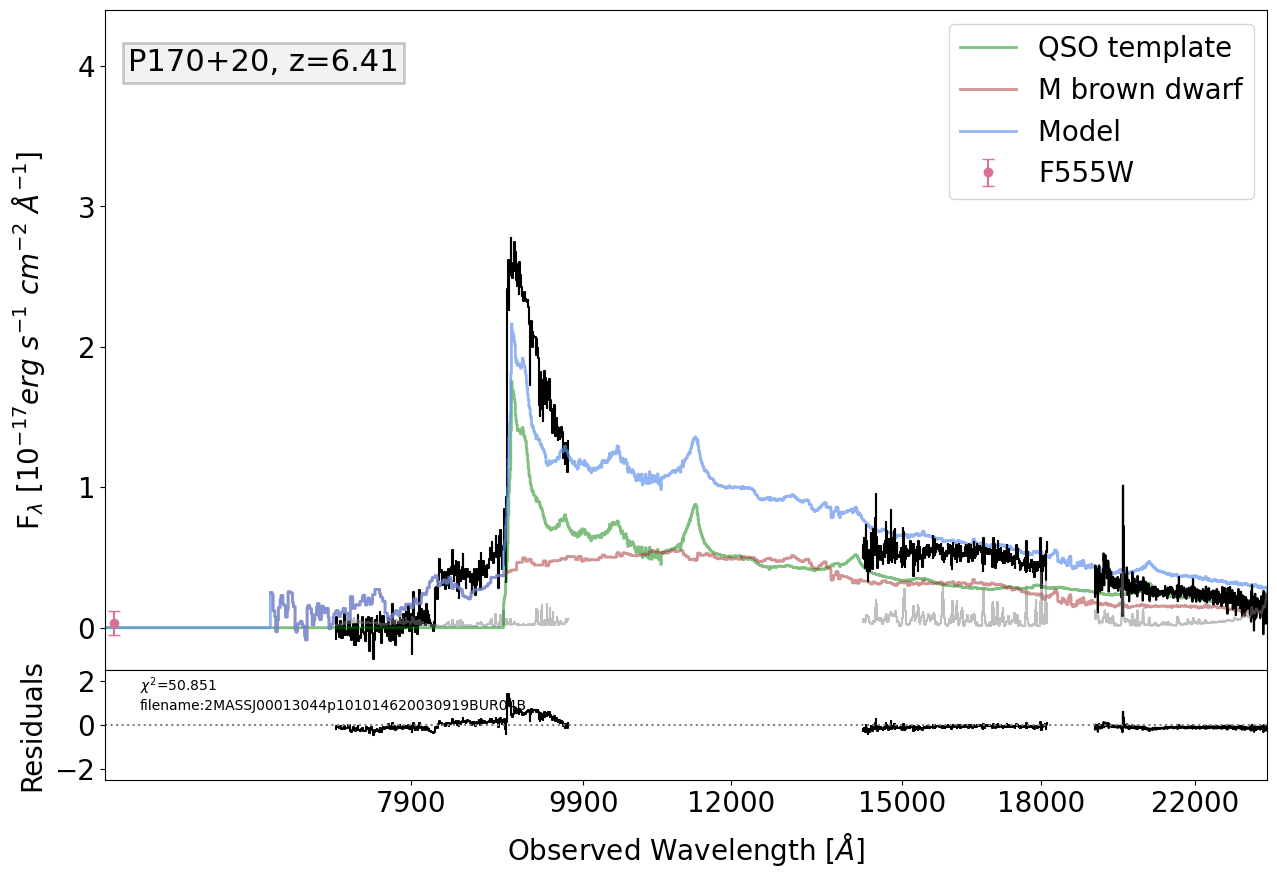

factor qso 0.5049906970300896


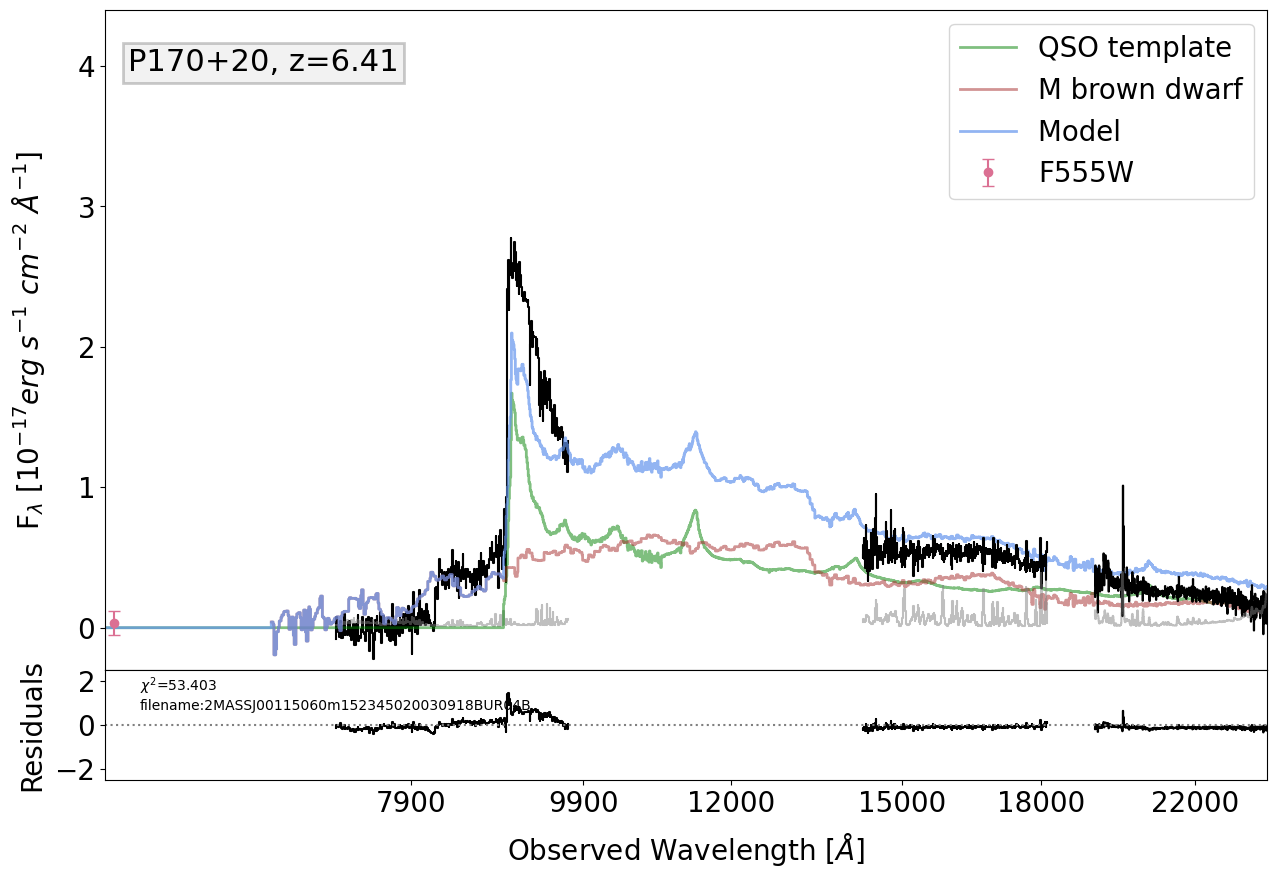

factor qso 0.25579131515947584


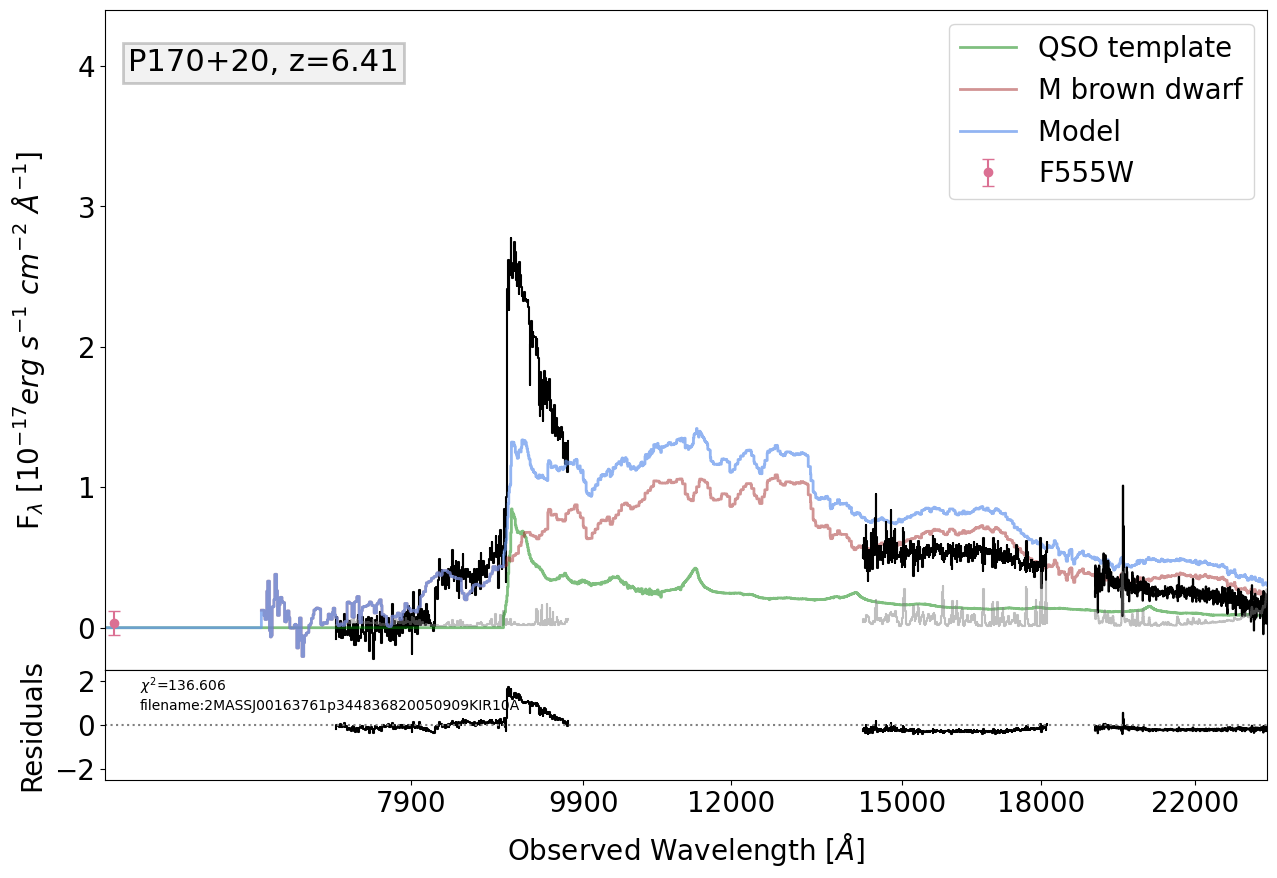

factor qso 0.48762873710454185


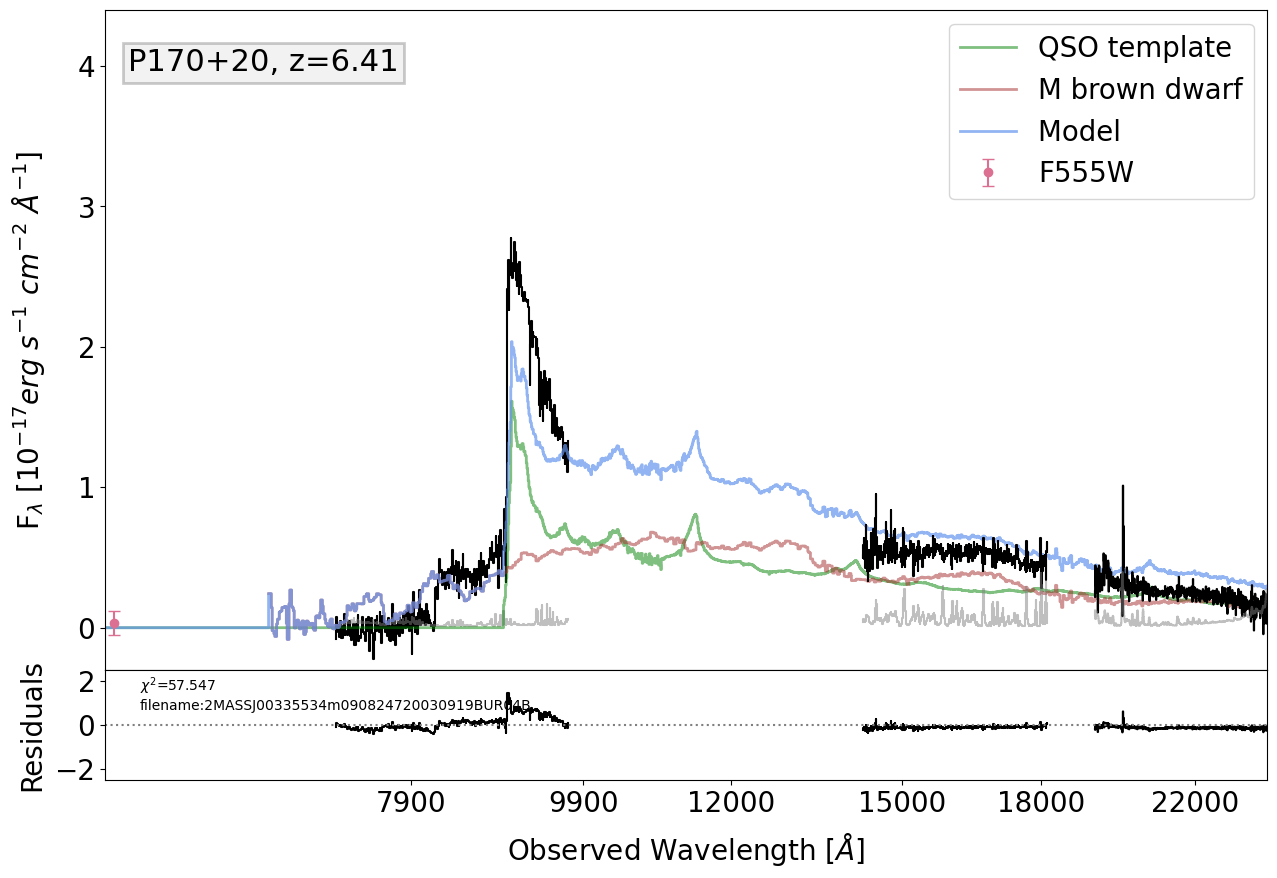

factor qso 0.25088053087848117


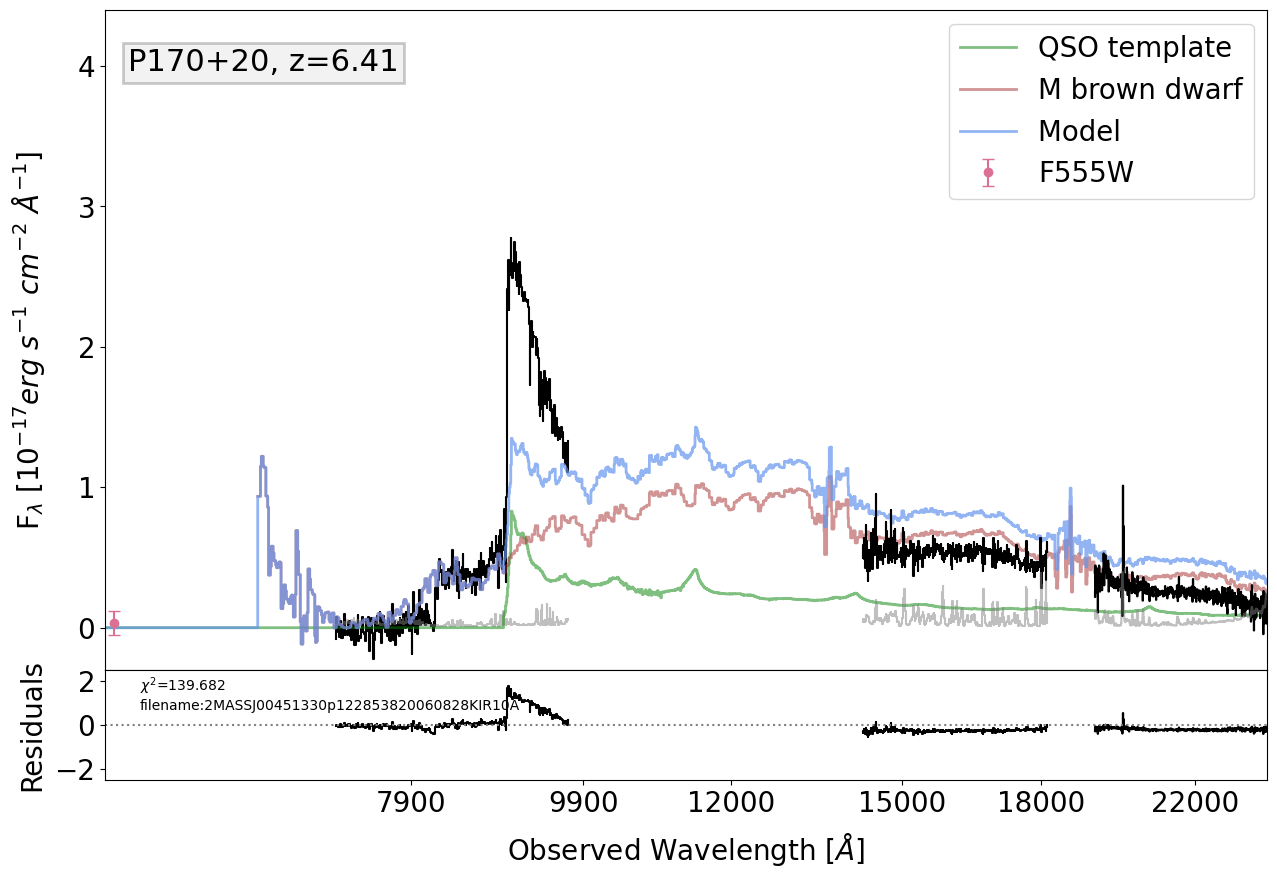

factor qso 0.362630700026434


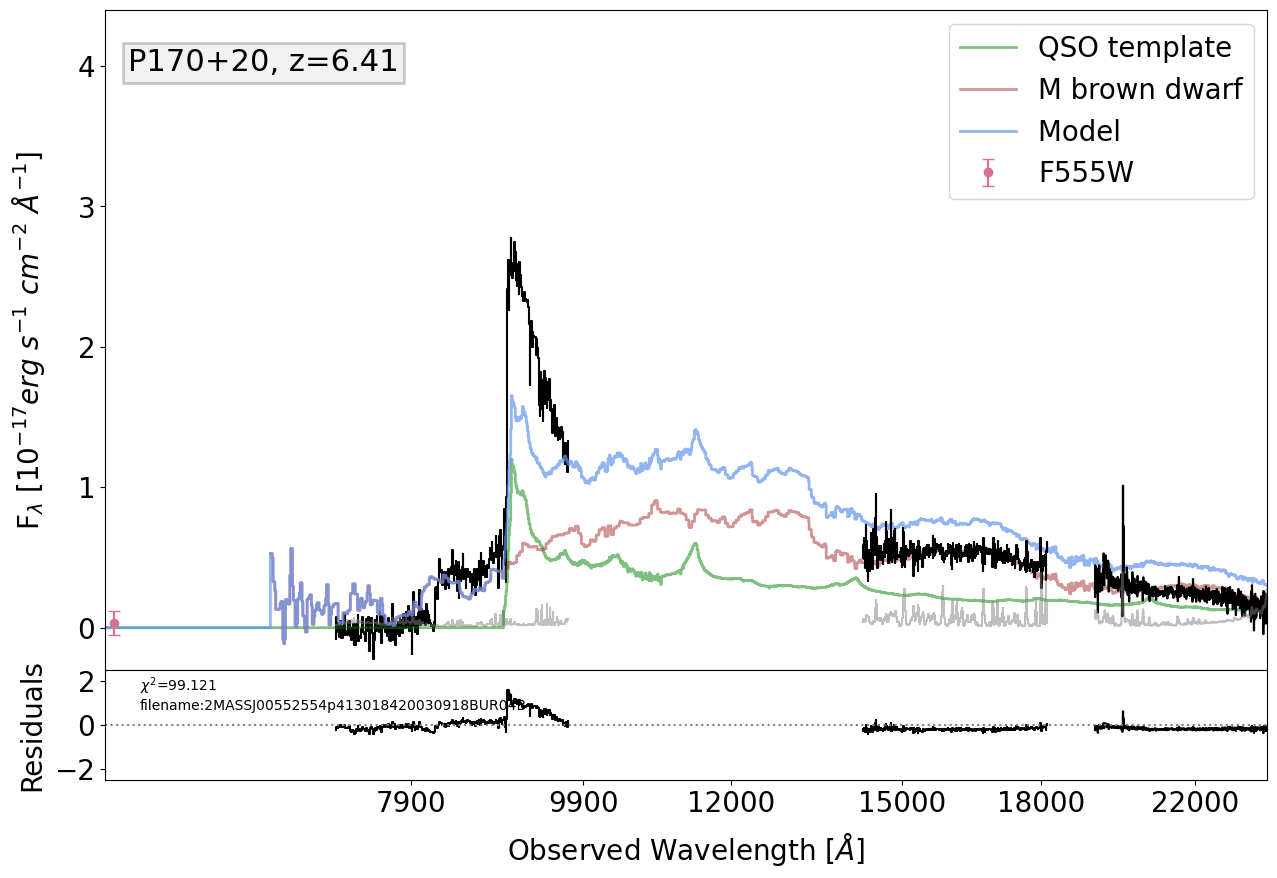

factor qso 0.5782661117640825


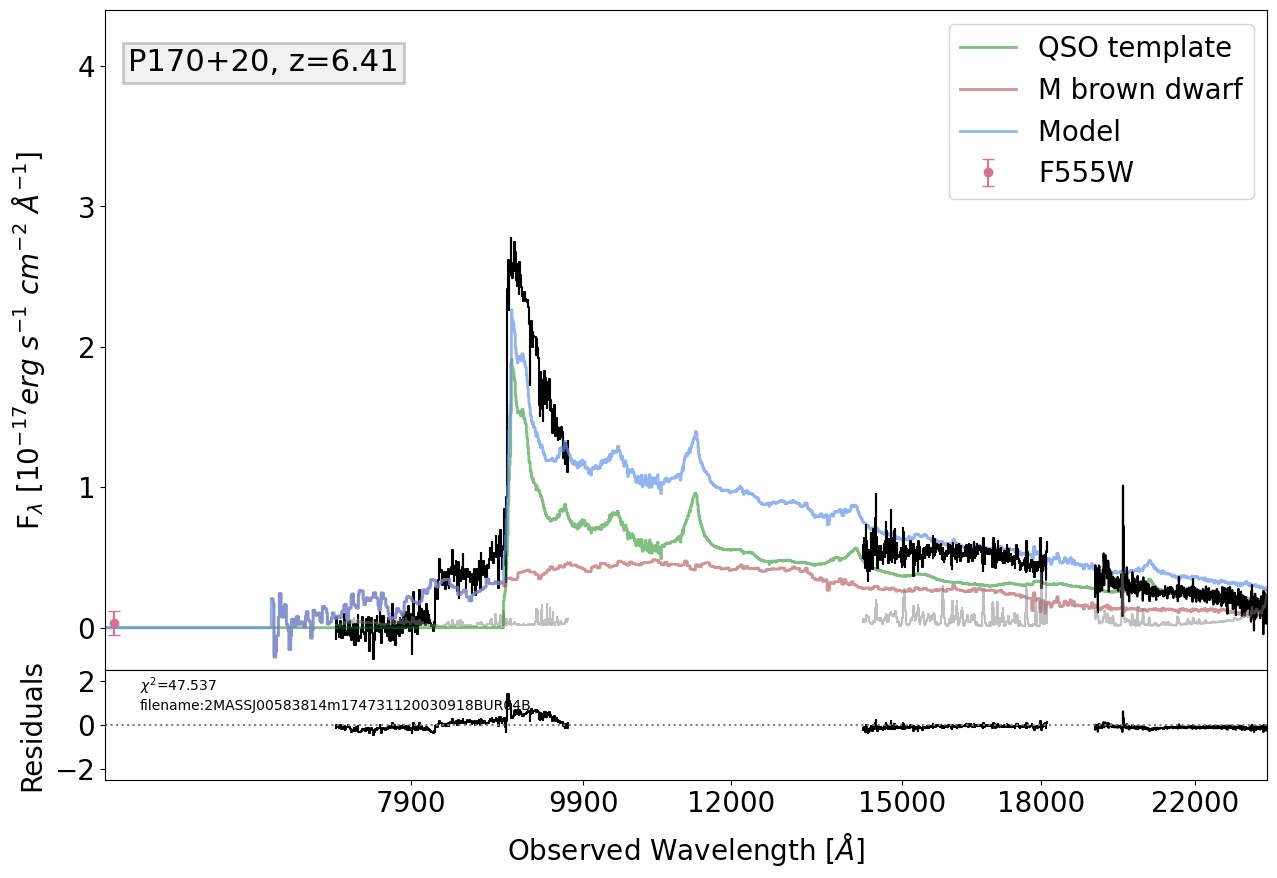

factor qso 0.3966167052712528


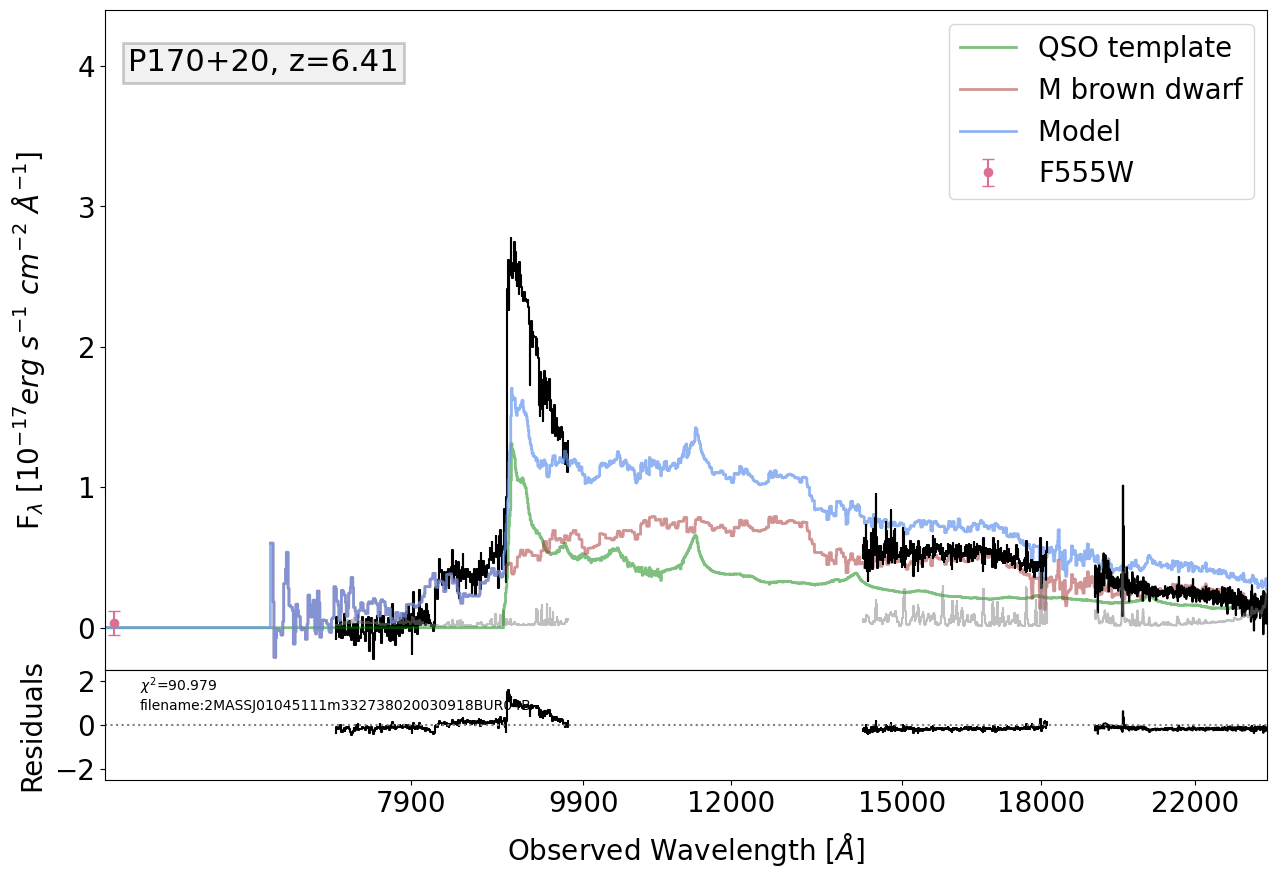

factor qso 0.2454149730018962


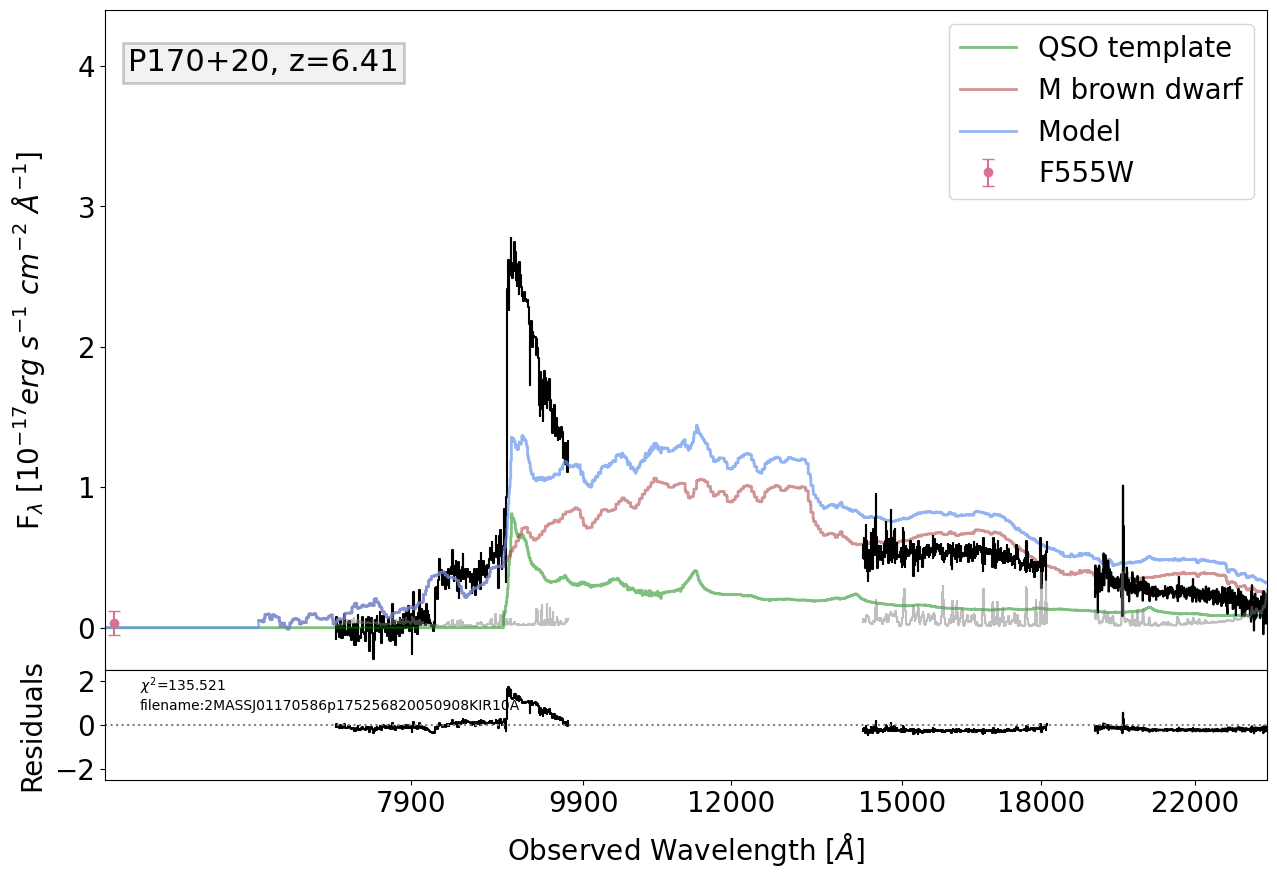

factor qso 0.15229165037643688


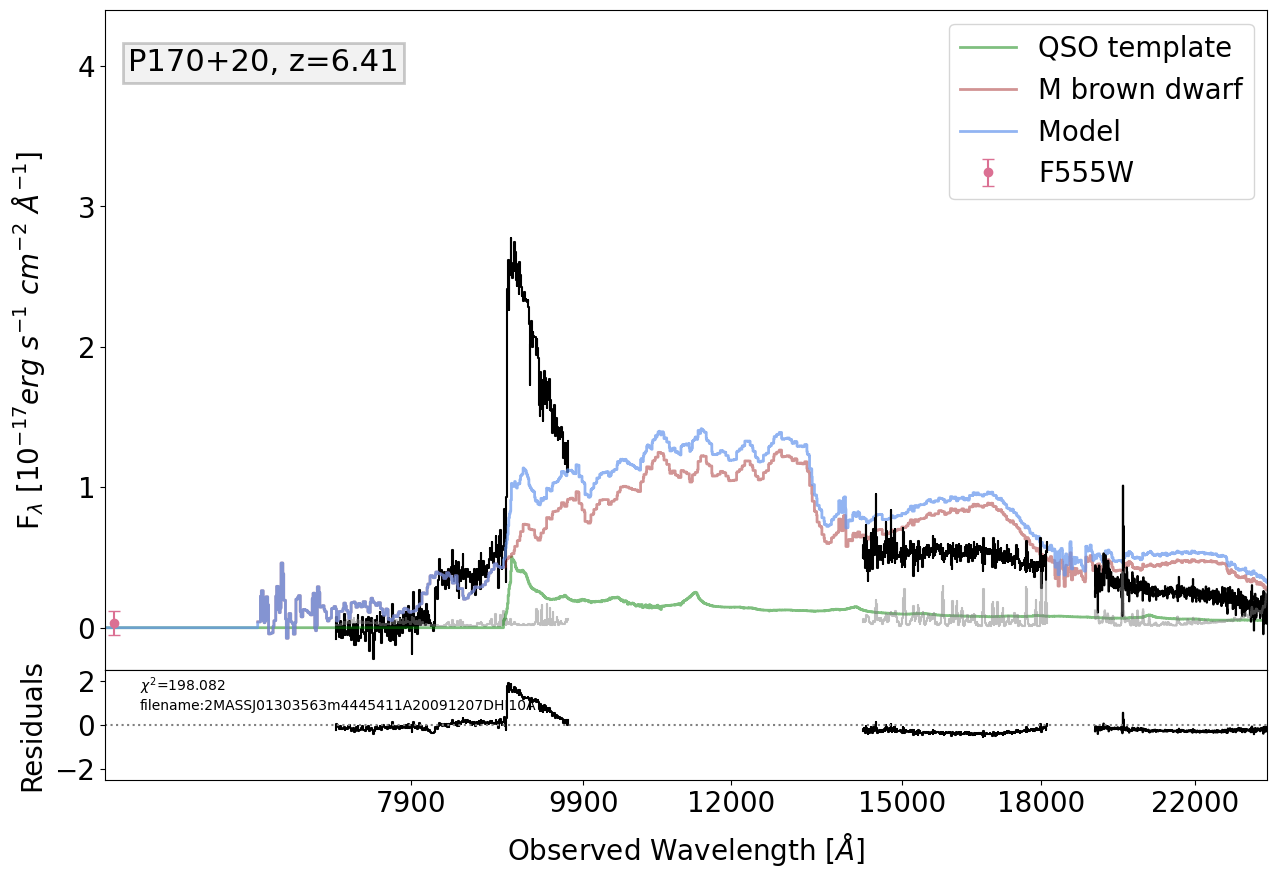

factor qso 0.26997130817344794


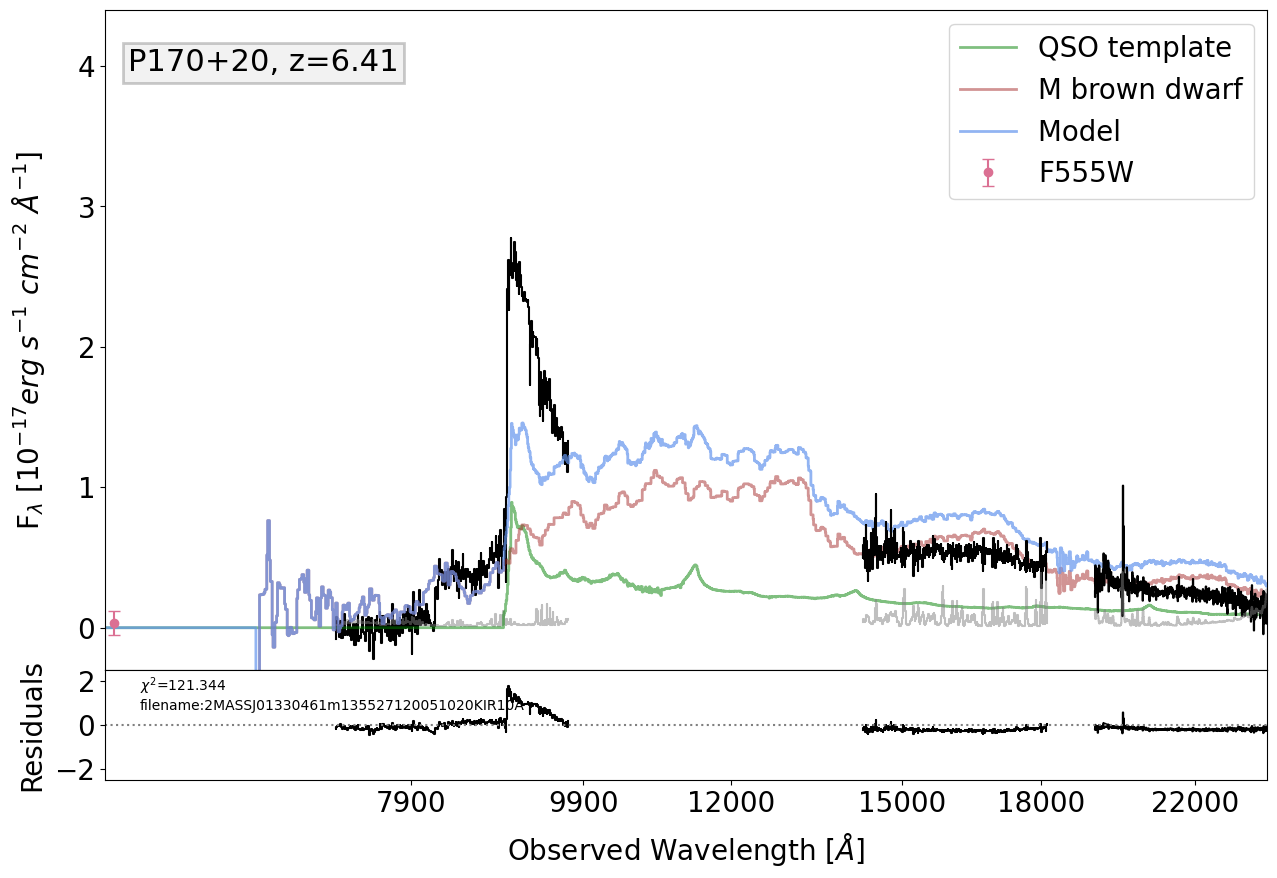

factor qso 0.6278503306712837


KeyboardInterrupt: 

<Figure size 1500x1000 with 0 Axes>

In [49]:
#Upload libraries necessary for plots
from matplotlib.ticker import MaxNLocator
import matplotlib.ticker as ticker
import matplotlib.gridspec as gridspec
import astropy.units as units
from specutils.manipulation import FluxConservingResampler
from specutils import Spectrum1D
import os
from astropy.table import Table

#Define function to test the Mdwarf models and save them
def Mdarf_function(filename):
    ruta_completa = os.path.join(ruta, filename)
    
    tabla = Table.read(ruta_completa, format='ascii')
    #tabla = Table.read('/users/aurora.mata/Downloads/MBD/DENISJ1245141m44290720070318LOO07B', format='ascii')
    #Try to do the resample here
    #Include resample data/ pix_size=7.7
    #First Give units to variables with filtered data
    #Total data
    newfluxbd=tabla['col2']*1e-17*units.erg/units.s/units.cm**2/units.AA
    newwavebd=tabla['col1']*1e4*units.AA
    newerrbd=tabla['col3']*1e-17*units.erg/units.s/units.cm**2/units.AA
    
    #convert to Spectrum from specutils 
    input_specbd=Spectrum1D(spectral_axis=newwavebd,flux=newfluxbd) 
    input_spec_errbd=Spectrum1D(spectral_axis=newwavebd,flux=newerrbd)
    
    #Resample here
    fluxconbd = FluxConservingResampler()
    new_spec_fluxconbd = fluxconbd(input_specbd, new_disp_grid)
    #new_spec_fluxcon_errbd = fluxconbd(input_spec_errbd, new_disp_grid)
    maskcurve=(originaldata_wave>969.47*(z+1))&(originaldata_wave<1210*(1+z))
    bdspectra=new_spec_fluxconbd.flux.value[maskcurve]
    
    def databrownd(x,c):
        f = c*bdspectra
        return f


    popt,pcov=curve_fit(databrownd,xdata=originaldata_wave[maskcurve],ydata=originaldata_flux[maskcurve],p0=[2.2])
    factorcbd=popt[0]
    
    # #Average bd
    # mask_a3=(originaldata_wave>16200)&(originaldata_wave<16400) 
    # mask_bt=(16200<new_spec_fluxconbd.spectral_axis.value)&(16400>new_spec_fluxconbd.spectral_axis.value)
    
    # av_qso3=np.mean(residual3[mask_a3])
    # av_bdm=np.mean(new_spec_fluxconbd.flux.value[mask_bt])
    # factorbdm3=av_qso3/av_bdm

    #####################
    maskresqso1=(originaldata_wave>1215*(1+z))&(originaldata_wave<1330*(1+z))
    maskresqso2=(originaldata_wave>1940.29*(z+1))&(originaldata_wave<2469.47*(z+1))
    maskresqso3=(originaldata_wave>2618.72*(z+1))&(originaldata_wave<3283.58*(z+1))
    maskresqso=maskresqso1|maskresqso2|maskresqso3
    bdscale=new_spec_fluxconbd.flux.value*factorcbd
    residualbddata=originaldata_flux-bdscale
    residualbddatac=tabc['FLUX'][maskresqso]

    def residual(x,c):
        f = c*residualbddatac
        return f
    
    
    #mask_no_nan = ~np.isnan(tabc['FLUX'])
    popt2,pcov2=curve_fit(residual,xdata=originaldata_wave[maskresqso],ydata=residualbddata[maskresqso],p0=[4.2])
    factorcresqso=popt2[0]
    
    print('factor qso', factorcresqso)
    # tabc = astropy.table.Table()
    # tabc['WAVE']= np.append(composite_wave[maskpr],wl[maskcs2])
    # tabc['FLUX']= np.append(composite_flux[maskpr],weighted_mean[maskcs2]*factorcresqso)
    ###########


    #sumspectra my model
    browndspectra=new_spec_fluxconbd.flux.value*factorcbd#*factorbdm3
    sumspectra=np.nan_to_num(browndspectra+(tabc['FLUX']*factorcresqso))#d
    substraction=originaldata_flux-sumspectra
    originaldata_err=new_spec_fluxcon_err.flux.value
    
    
    mask1= (originaldata_wave>7156.777)&(originaldata_wave<9710)
    mask2= (originaldata_wave>14250)&(originaldata_wave<18150) 
    mask3= (originaldata_wave>19300)&(originaldata_wave<24181.477) 


    #Calculation of chi square
    maskf= mask1 | mask2 | mask3
    chisquare=np.sum((substraction[maskf])**2/((originaldata_err[maskf])**2))
    reducedchi=chisquare/(len(originaldata_flux[maskf])-2)
    #chisquare=np.sum(substraction[maskf])**2/np.std(originaldata_flux[maskf])**2
    #reducedchi=chisquare/len(originaldata_flux[maskf])-2
    reducedchi
    #print(r'$\chi^2$='+str(np.round(reducedchi,3)))


    #All plotting from here
    fig = plt.figure(figsize=(15, 10))
    gs = gridspec.GridSpec(2, 1, height_ratios=[3, 0.5])
    
    ax1 = fig.add_subplot(gs[0])
    
    #Primer parte
    ax1.step(originaldata_wave[mask1],originaldata_flux[mask1],color='black')
    ax1.step(originaldata_wave[mask1], originaldata_err[mask1] ,color='grey',alpha=0.5)
    
    ax1.step(originaldata_wave,tabc['FLUX']*factorcresqso,label='QSO template',alpha=0.5,color='green',linewidth=2)
    ax1.step(originaldata_wave,browndspectra,label='M brown dwarf',alpha=0.5,color='brown',linewidth=2)
    ax1.step(originaldata_wave,sumspectra,label='Model ',color='cornflowerblue',alpha=0.7,linewidth=2)
    
    #Segunda parte
    ax1.step(originaldata_wave[mask2],originaldata_flux[mask2],color='black')
    ax1.step(originaldata_wave[mask2], originaldata_err[mask2] ,color='grey',alpha=0.5)
    
    #ax1.step(originaldata_wave[mask2],tabc['FLUX'][mask2]*factorcresqso,alpha=0.5,color='green',linewidth=2)
    #ax1.step(originaldata_wave[mask2],browndspectra[mask2],alpha=0.5,color='brown',linewidth=2)
    #ax1.step(originaldata_wave[mask2],sumspectra[mask2],alpha=0.7,color='cornflowerblue',linewidth=2)
    
    #Tercera parte
    ax1.step(originaldata_wave[mask3], originaldata_flux[mask3],color='black')
    ax1.step(originaldata_wave[mask3], originaldata_err[mask3] ,color='grey',alpha=0.5)
    
    #ax1.step(originaldata_wave[mask3],tabc['FLUX'][mask3]*factorcresqso,alpha=0.5,color='green',linewidth=2)
    #ax1.step(originaldata_wave[mask3],browndspectra[mask3],alpha=0.5,color='brown',linewidth=2)
    #ax1.step(originaldata_wave[mask3],sumspectra[mask3],alpha=0.7,color='cornflowerblue',linewidth=2)
    
    #ax1.legend(fontsize=19.9,loc='upper right')
    ax1.tick_params(labelbottom=False) 
    bbox=dict(facecolor='silver',   # Color de fondo
                  edgecolor='black',          # Borde
                  linewidth=2,
                  alpha=0.2)
    ax1.text(0.02,0.92,'P170+20, z=6.41',va='center', rotation='horizontal',fontsize=22,bbox=bbox,transform=ax1.transAxes)
    ax1.set_ylabel('F$_{\lambda}$ $[10^{-17} erg~s^{-1}~cm^{-2}~\AA^{-1}]$',fontsize=20,labelpad=22)
    ax1.yaxis.set_tick_params(labelsize=20)
    #ax1.set_ylabel('$f_{\lambda}$ $(10^{-17} erg~s^{-1}~cm^{-2}~\AA^{-1})$',fontsize=16)
    ax1.set_xlim(5300,24181.477)#(7156.777,24181.477)
    ax1.set_ylim(-0.3e-17,4.4e-17)
    plt.errorbar(x=5361, y=3.2e-19, yerr=0.85e-18, fmt='o', capsize=4,label='F555W',color='palevioletred')

    #ax1.plot(originaldata_wave,  residual3,label='Substraction data-templates' )

 
    
    
    
    #Lower plot
    ax2 = fig.add_subplot(gs[1], sharex=ax1)
    ax2.step(originaldata_wave[mask1],substraction[mask1],color='black')
    ax2.step(originaldata_wave[mask2],substraction[mask2],color='black')
    ax2.step(originaldata_wave[mask3],substraction[mask3],color='black')
    ax2.axhline(y=0,color='grey',linestyle='dotted')
    #ax2.plot([7156.777, 9736.701], [0, 0], color='grey', linestyle='dotted')
    #ax2.plot([14250, 18150], [0, 0], color='grey', linestyle='dotted')
    #ax2.plot([19300, 24181.477], [0, 0], color='grey', linestyle='dotted')
    ax2.xaxis.set_tick_params(labelsize=20)
    #ax2.set_title('Original data-(QSO template + Brown Dwarf)')
    ax2.set_ylim(-2.5e-17, 2.5e-17)
    #ax2.legend(fontsize=14)
    ax2.get_yaxis().get_offset_text().set_visible(False)
    #ax2.set_ylabel('Residuals',fontsize=16)
    ax2.set_xlim(5300,24181.477)#(7156.777,24181.477)

    #ax2.text(0.03, 0.95, '$\chi^2$='+str(np.round(reducedchi,3)), transform=ax2.transAxes,
             #fontsize=10, verticalalignment='top')
    
    
    #fig.text(-0.015, 0.5, '$F_{\lambda}$ $[10^{-17} erg~s^{-1}~cm^{-2}~\AA^{-1}]$', va='center', rotation='vertical',fontsize=20)
    
    ax2.set_ylabel('Residuals',fontsize=20,labelpad=6)
    ax1.get_yaxis().get_offset_text().set_visible(False)
    ax1.get_xaxis().get_offset_text().set_visible(False)
    
    #ax1.ticklabel_format(useOffset=False)

    plt.xlabel(r'Observed Wavelength [$\AA$]',fontsize=20,ha='center', va='center',labelpad=23)
    #plt.xscale('log') #Graficar en log
    plt.subplots_adjust(hspace=0.0)
    plt.xscale('log')
    
    ax2.yaxis.set_tick_params(labelsize=20)
    #Numero de ticks
    ax2.xaxis.set_major_locator(MaxNLocator(nbins=6))
    ax1.xaxis.set_major_locator(MaxNLocator(nbins=0))
    ax1.yaxis.set_major_locator(MaxNLocator(nbins=5))

    labels=[7900,9900,12000,15000,18000,22000]
    ax2.set_xticks(labels)
    from matplotlib.ticker import NullLocator
    ax2.get_xaxis().set_minor_locator(NullLocator())
    #poner labels en escala normal
    formatter = ticker.ScalarFormatter()
    formatter.set_scientific(False)
    formatter.set_useOffset(False)
    formatter.set_powerlimits((0, 0))  # desactiva cambio automático a potencia

    # aplicar formateador al eje X
    ax2.xaxis.set_major_formatter(formatter)
    
    ax2.ticklabel_format(style='plain', axis='x')
    ax2.axvspan(11000,11500, color='white', zorder=0)
    ax1.axvspan(11000,11500, color='white', zorder=0)

    ax2.axvspan(12100,12500, color='white', zorder=0)
    ax1.axvspan(12100,12500, color='white', zorder=0)
    #plt.savefig('/users/aurora.mata/Downloads/Plot',bbox_inches='tight',dpi=400) #dpi=400
    #ax1.plot(originaldata_wave[mask1],residualbddata[mask1],alpha=0.2,color='violet',label='data-bd')
    #ax1.plot(originaldata_wave[mask2],residualbddata[mask2],alpha=0.2,color='violet')
    #ax1.plot(originaldata_wave[mask3],residualbddata[mask3],alpha=0.2,color='violet')
    ax2.text(0.03, 0.95, '$\chi^2$='+str(np.round(reducedchi,3))+'\n'+'filename:'+filename, transform=ax2.transAxes,
             fontsize=10, verticalalignment='top')
    ax1.legend(fontsize=19.9,loc='upper right')
    
    #Here we save the models in a new folder to choose the best one. All models include the chisquare value
    nombre_salida = os.path.splitext(filename)[0] + '.png'
    ruta_salida=r"C:\Users\aurom\Downloads\Auroracodesthatwork\MBD\results"
    ruta_plot = os.path.join(ruta_salida, nombre_salida)
    #plt.savefig(ruta_plot,bbox_inches='tight') #Disable in case you dont want to save them
    plt.show()
    plt.close()
    #ax1.plot(originaldata_wave[maskresqso],residualbddata[maskresqso])
    
# Route for the folder where all the Mdwarf models are
ruta = r"C:\Users\aurom\Downloads\Auroracodesthatwork\MBD\BDtemplates"  

#Here for Mdwarf loop / Loop will test all the templates of Mdwarf and calculate the chisquare to select one
for nombre_archivo in os.listdir(ruta):
    if os.path.isfile(os.path.join(ruta, nombre_archivo)):
        try:
            Mdarf_function(nombre_archivo)  # Here pass the name of the file
        except Exception:
            continue  # Go to next one in case of error

# Final model with the best fit M-dwarf model
The final model is M-dwarf (2MASSJ18112466p374851320030522BUR04B) and joined quasar templates (Selsing+Banados).
The final data is GMOS, LBT, F2.

factor cbd 0.3984578239405722
factor qso 0.6729794099182174
$\chi^2$=38.833


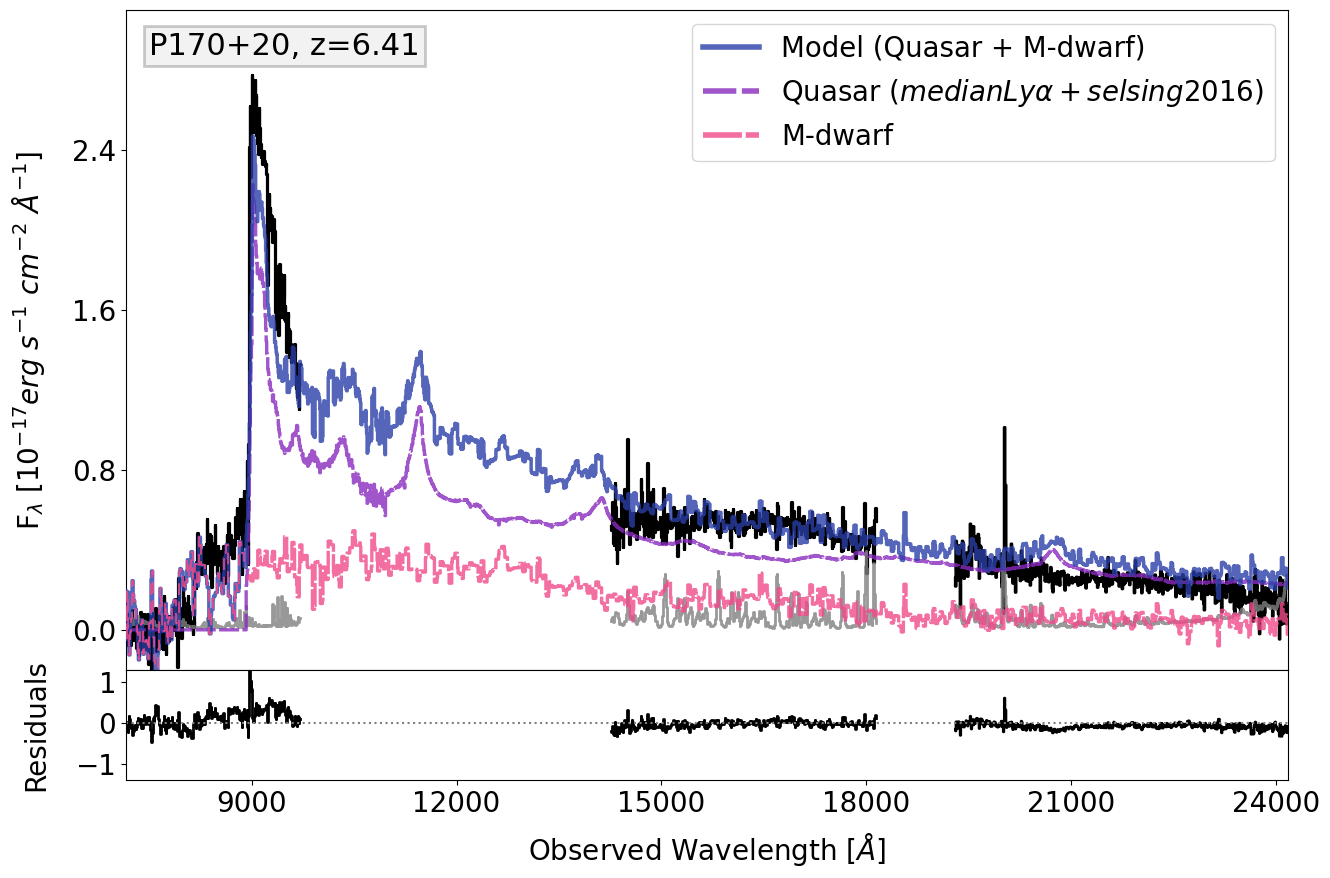

In [42]:
    from matplotlib.ticker import MaxNLocator
    import matplotlib.ticker as ticker
    import matplotlib.gridspec as gridspec
    import astropy.units as units
    from specutils.manipulation import FluxConservingResampler
    from specutils import Spectrum1D
    import os
    from astropy.table import Table
    tabla =Table.read(r"C:\Users\aurom\Downloads\Auroracodesthatwork\MBD\BDtemplates\2MASSJ18112466p374851320030522BUR04B" , format='ascii')
    #Table.read('\\Users\\aurom\\Downloads\\Auroracodesthatwork\\MBD\\BDtemplates\\2MASSJ18112466p374851320030522BUR04B', format='ascii')
    #Try to do the resample here
    #Include resample data/ pix_size=7.7
    #First Give units to variables with filtered data
    #Total data
    newfluxbd=tabla['col2']*1e-17*units.erg/units.s/units.cm**2/units.AA
    newwavebd=tabla['col1']*1e4*units.AA
    newerrbd=tabla['col3']*1e-17*units.erg/units.s/units.cm**2/units.AA
    
    #convert to Spectrum from specutils 
    input_specbd=Spectrum1D(spectral_axis=newwavebd,flux=newfluxbd) 
    input_spec_errbd=Spectrum1D(spectral_axis=newwavebd,flux=newerrbd)
    
    #Resample here
    fluxconbd = FluxConservingResampler()
    new_spec_fluxconbd = fluxconbd(input_specbd, new_disp_grid)
    #new_spec_fluxcon_errbd = fluxconbd(input_spec_errbd, new_disp_grid)
    maskcurve=(originaldata_wave>969.47*(z+1))&(originaldata_wave<1210*(1+z))
    bdspectra=new_spec_fluxconbd.flux.value[maskcurve]
    
    def databrownd(x,c):
        f = c*bdspectra
        return f


    popt,pcov=curve_fit(databrownd,xdata=originaldata_wave[maskcurve],ydata=originaldata_flux[maskcurve],p0=[2.2])
    factorcbd=popt[0]
    
    # #Average bd
    # mask_a3=(originaldata_wave>16200)&(originaldata_wave<16400) 
    # mask_bt=(16200<new_spec_fluxconbd.spectral_axis.value)&(16400>new_spec_fluxconbd.spectral_axis.value)
    
    # av_qso3=np.mean(residual3[mask_a3])
    # av_bdm=np.mean(new_spec_fluxconbd.flux.value[mask_bt])
    # factorbdm3=av_qso3/av_bdm

    #####################
    maskresqso1=(originaldata_wave>1215*(1+z))&(originaldata_wave<1330*(1+z))
    maskresqso2=(originaldata_wave>1940.29*(z+1))&(originaldata_wave<2469.47*(z+1))
    maskresqso3=(originaldata_wave>2618.72*(z+1))&(originaldata_wave<3283.58*(z+1))
    maskresqso=maskresqso1|maskresqso2|maskresqso3
    bdscale=new_spec_fluxconbd.flux.value*factorcbd
    residualbddata=originaldata_flux-bdscale
    residualbddatac=tabc['FLUX'][maskresqso]

    def residual(x,c):
        f = c*residualbddatac
        return f
    
    
    #mask_no_nan = ~np.isnan(tabc['FLUX'])
    popt2,pcov2=curve_fit(residual,xdata=originaldata_wave[maskresqso],ydata=residualbddata[maskresqso],p0=[4.2])
    factorcresqso=popt2[0]
    print('factor cbd', factorcbd)
    print('factor qso', factorcresqso)
    # tabc = astropy.table.Table()
    # tabc['WAVE']= np.append(composite_wave[maskpr],wl[maskcs2])
    # tabc['FLUX']= np.append(composite_flux[maskpr],weighted_mean[maskcs2]*factorcresqso)
    ###########


    #sumspectra my model
    browndspectra=new_spec_fluxconbd.flux.value*factorcbd#*factorbdm3
    sumspectra=np.nan_to_num(browndspectra+(tabc['FLUX']*factorcresqso))#d
    substraction=originaldata_flux-sumspectra
    originaldata_err=new_spec_fluxcon_err.flux.value
    
    
    mask1= (originaldata_wave>7156.777)&(originaldata_wave<9710)
    mask2= (originaldata_wave>14250)&(originaldata_wave<18150) 
    mask3= (originaldata_wave>19300)&(originaldata_wave<24181.477) 


    #Calculation of chi square
    maskf= mask1 | mask2 | mask3
    #chisquare=np.sum(substraction[maskf])**2/np.std(originaldata_flux[maskf])**2
    #reducedchi=chisquare/len(originaldata_flux[maskf])-2
    chisquare=np.sum((substraction[maskf])**2/((originaldata_err[maskf])**2))
    reducedchi=chisquare/(len(originaldata_flux[maskf])-2)
    print(r'$\chi^2$='+str(np.round(reducedchi,3)))


    #All plotting from here
    fig = plt.figure(figsize=(15, 10))
    gs = gridspec.GridSpec(2, 1, height_ratios=[3, 0.5])
    
    ax1 = fig.add_subplot(gs[0])
    maskla=(originaldata_wave>8924)
    maskla2=(originaldata_wave<8924)
    #Primer parte
    ax1.step(originaldata_wave[mask1],originaldata_flux[mask1],color='black',linewidth=2.3,zorder=0)
    ax1.step(originaldata_wave[mask1], originaldata_err[mask1] ,color='grey',alpha=0.8,linewidth=2)

    ax1.step(originaldata_wave,sumspectra,label='Model (Quasar + M-dwarf)',alpha=0.8,color='#2A3FA8',linewidth=2.5,zorder=3)
    ax1.step(originaldata_wave,tabc['FLUX']*factorcresqso,label='Quasar ($medianLyα + selsing2016$)',alpha=0.8,color='#8A2BBF',linewidth=2.4,dashes=[6, 1])
    ax1.step(originaldata_wave[maskla],browndspectra[maskla],label='M-dwarf',alpha=0.8,color="#F04A8A",linewidth=2.4,linestyle='-', dashes=[7, 0.7],zorder=3)
    ax1.step(originaldata_wave[maskla2],browndspectra[maskla2],alpha=0.95,color="#F04A8A",linewidth=1.2,linestyle='-', dashes=[7, 4],zorder=3)

    
    #Segunda parte
    ax1.step(originaldata_wave[mask2],originaldata_flux[mask2],color='black',linewidth=2.3,zorder=0)
    ax1.step(originaldata_wave[mask2], originaldata_err[mask2] ,color='grey',alpha=0.8,linewidth=2)
    
    #ax1.step(originaldata_wave[mask2],tabc['FLUX'][mask2]*factorcresqso,alpha=0.5,color='green',linewidth=2)
    #ax1.step(originaldata_wave[mask2],browndspectra[mask2],alpha=0.9,color='pink',linewidth=2.2,linestyle='--',zorder=3)
    #ax1.step(originaldata_wave[mask2],sumspectra[mask2],alpha=0.7,color='cornflowerblue',linewidth=2)
    
    #Tercera parte
    ax1.step(originaldata_wave[mask3], originaldata_flux[mask3],color='black',linewidth=2.3,zorder=0)
    ax1.step(originaldata_wave[mask3], originaldata_err[mask3] ,color='grey',alpha=0.8,linewidth=2.3,zorder=1)
    
    #ax1.step(originaldata_wave[mask3],tabc['FLUX'][mask3]*factorcresqso,alpha=0.5,color='green',linewidth=2)
    #ax1.step(originaldata_wave[mask3],browndspectra[mask3],color='brown',linewidth=2)
    #ax1.step(originaldata_wave[mask3],sumspectra[mask3],color='cornflowerblue',linewidth=2)
    
    
    ax1.tick_params(labelbottom=False) 
    bbox=dict(facecolor='silver',   # Color de fondo
                  edgecolor='black',          # Borde
                  linewidth=2,
                  alpha=0.2)
    ax1.text(0.02,0.945,'P170+20, z=6.41',va='center', rotation='horizontal',fontsize=22,bbox=bbox,transform=ax1.transAxes)
    ax1.set_ylabel('F$_{\lambda}$ $[10^{-17} erg~s^{-1}~cm^{-2}~\AA^{-1}]$',fontsize=20,labelpad=18)
    ax1.yaxis.set_tick_params(labelsize=20)
    #ax1.set_ylabel('$f_{\lambda}$ $(10^{-17} erg~s^{-1}~cm^{-2}~\AA^{-1})$',fontsize=16)
    ax1.set_xlim(7156.777,14181.477)
    ax1.set_ylim(-0.2e-17,3.1e-17)
    #ax1.axvline(9000)

    #ax1.plot(originaldata_wave,  residual3,label='Substraction data-templates' )

 
    
    
    
    #Lower plot
    ax2 = fig.add_subplot(gs[1], sharex=ax1)
    ax2.step(originaldata_wave[mask1],substraction[mask1],color='black',linewidth=2)
    ax2.step(originaldata_wave[mask2],substraction[mask2],color='black',linewidth=2)
    ax2.step(originaldata_wave[mask3],substraction[mask3],color='black',linewidth=2)
    ax2.axhline(y=0,color='grey',linestyle='dotted')
    #ax2.plot([7156.777, 9736.701], [0, 0], color='grey', linestyle='dotted')
    #ax2.plot([14250, 18150], [0, 0], color='grey', linestyle='dotted')
    #ax2.plot([19300, 24181.477], [0, 0], color='grey', linestyle='dotted')
    ax2.xaxis.set_tick_params(labelsize=20)
    #ax2.set_title('Original data-(QSO template + Brown Dwarf)')
    ax2.set_ylim(-1.4e-17, 1.3e-17)
    #ax2.legend(fontsize=14)
    ax2.get_yaxis().get_offset_text().set_visible(False)
    #ax2.set_ylabel('Residuals',fontsize=16)
    ax2.set_xlim(7156.777,24181.477)

    #ax2.text(0.03, 0.95, '$\chi^2$='+str(np.round(reducedchi,3)), transform=ax2.transAxes,
             #fontsize=10, verticalalignment='top')
    
    
    #fig.text(-0.015, 0.5, '$F_{\lambda}$ $[10^{-17} erg~s^{-1}~cm^{-2}~\AA^{-1}]$', va='center', rotation='vertical',fontsize=20)
    
    ax2.set_ylabel('Residuals',fontsize=20,labelpad=18)
    ax1.get_yaxis().get_offset_text().set_visible(False)
    ax1.get_xaxis().get_offset_text().set_visible(False)
    
    #ax1.ticklabel_format(useOffset=False)

    plt.xlabel(r'Observed Wavelength [$\AA$]',fontsize=20,ha='center', va='center',labelpad=23)
    #plt.xscale('log') #Graficar en log
    plt.subplots_adjust(hspace=0.0)
    #plt.xscale('log')
    
    ax2.yaxis.set_tick_params(labelsize=20)
    #Numero de ticks
    ax2.xaxis.set_major_locator(MaxNLocator(nbins=6))
    #ax1.xaxis.set_major_locator(MaxNLocator(nbins=0))
    ax1.yaxis.set_major_locator(MaxNLocator(nbins=5))

    
    ax1.legend(fontsize=19.9,loc='upper right')
    leg = ax1.legend(fontsize=19.9)
    for line in leg.get_lines():
        line.set_linewidth(4)

    #plt.savefig('\MBD',bbox_inches='tight',dpi=400) #dpi=400 #Activate to save the model
    #ax1.plot(originaldata_wave[mask1],residualbddata[mask1],alpha=0.2,color='magenta')
    #ax1.plot(originaldata_wave[mask2],residualbddata[mask2],alpha=0.2,color='magenta')
    #ax1.plot(originaldata_wave[mask3],residualbddata[mask3],alpha=0.2,color='magenta')
    
